## Frequency, length & morphological complexity


In [ ]:
!pip install pandas wordfreq datasets

##### Load morphological segmentation dataset:

In [1]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("browndw/morphoseg-en")

df = pd.DataFrame(dataset["train"])
print(df.head())

           word            segments        segment_roles  \
0     tunnyfish       [tunny, fish]         [base, base]   
1      spareful        [spare, ful]        [base, affix]   
2    sallowness      [sallow, ness]        [base, affix]   
3       wuffled        [wuffle, ed]        [base, affix]   
4  workstations  [work, station, s]  [base, base, affix]   

            segment_pos    original_segments      source subcategory  
0          [Noun, Noun]        [tunny, fish]  wiki_morph        None  
1   [Adjective, Suffix]        [spare, -ful]  wiki_morph        None  
2   [Adjective, Suffix]      [sallow, -ness]  wiki_morph        None  
3        [Verb, Suffix]         [wuffle, -d]  wiki_morph        None  
4  [Noun, Noun, Suffix]  [work, station, -s]  wiki_morph        None  


##### About the segmentation dataset:

MorphoSeg-EN is an English morphological segmentation dataset designed for evaluating and training computational models that learn word structure. It provides gold-standard segmentations of English words into morphemes, enabling research on morphology-aware natural language processing and linguistic analysis. 

- publicly available, dataset and additional information here: https://huggingface.co/datasets/browndw/morphoseg-en/blob/main/README.md

##### Compute morpheme counts and word length:

In [2]:
df["morpheme_count"] = df["segments"].apply(len)
df["length_letters"] = df["word"].str.len()

In [ ]:
df.head()

In [ ]:
df.info()

##### Add frequency information:

In [3]:
from wordfreq import zipf_frequency

df["frequency"] = df["word"].apply(lambda w: zipf_frequency(w, "en"))

In [4]:
df.head()

,word,segments,segment_roles,segment_pos,original_segments,source,subcategory,morpheme_count,length_letters,frequency
0,tunnyfish,"[tunny, fish]","[base, base]","[Noun, Noun]","[tunny, fish]",wiki_morph,None,2,9,0.00
1,spareful,"[spare, ful]","[base, affix]","[Adjective, Suffix]","[spare, -ful]",wiki_morph,None,2,8,0.00
2,sallowness,"[sallow, ness]","[base, affix]","[Adjective, Suffix]","[sallow, -ness]",wiki_morph,None,2,10,0.00
3,wuffled,"[wuffle, ed]","[base, affix]","[Verb, Suffix]","[wuffle, -d]",wiki_morph,None,2,7,0.00
4,workstations,"[work, station, s]","[base, base, affix]","[Noun, Noun, Suffix]","[work, station, -s]",wiki_morph,None,3,12,2.82


##### About the frequency data:

- wordfreq is a Python library that provides word frequency estimates derived from very large text corpora. The underlying data comes from the Exquisite Corpus (https://github.com/LuminosoInsight/exquisite-corpus), which aggregates text from multiple sources such as: Wikipedia, news sites, books, subtitles, web crawl data.

- zipf_frequency() returns the log10 frequency per billion tokens

##### Some filtering:

In [5]:
df = df[df["length_letters"] >= 3] # remove very short words
df = df[df["morpheme_count"] <= 5] # remove super-long compounds
df = df[df["frequency"] > 0] # remove unattested words
# remove duplicates:
df = df.drop_duplicates(subset="word")
df = df.reset_index(drop=True)
# remove capitalization variants:
df = df[df["word"].str.match("^[a-z]+$")] 

df.info()
df.sort_values(by='frequency', ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56947 entries, 0 to 61690
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   word               56947 non-null  object 
 1   segments           56947 non-null  object 
 2   segment_roles      56947 non-null  object 
 3   segment_pos        56947 non-null  object 
 4   original_segments  56947 non-null  object 
 5   source             56947 non-null  object 
 6   subcategory        111 non-null    object 
 7   morpheme_count     56947 non-null  int64  
 8   length_letters     56947 non-null  int64  
 9   frequency          56947 non-null  float64
dtypes: float64(1), int64(2), object(7)
memory usage: 4.8+ MB


,word,segments,segment_roles,segment_pos,original_segments,source,subcategory,morpheme_count,length_letters,frequency
9626,and,[and],[base],[Conjunction],[and],wiki_morph,None,1,3,7.41
60837,have,[have],[base],[Verb],[have],wiki_morph,None,1,4,6.71
44203,from,[from],[base],[Preposition],[from],wiki_morph,None,1,4,6.63
9379,but,"[be, out]","[affix, base]","[Prefix, Adverb]","[be-, out]",wiki_morph,None,2,3,6.63
43897,has,"[have, s]","[base, affix]","[Verb, Suffix]","[have, -s]",wiki_morph,None,2,3,6.37
51810,more,[more],[base],[Determiner],[more],wiki_morph,None,1,4,6.36
17737,which,"[who, like]","[base, base]","[Determiner, Preposition]","[who, like]",wiki_morph,None,2,5,6.30
32909,her,[her],[base],[Pronoun],[her],wiki_morph,None,1,3,6.30
58768,time,[time],[base],[Interjection],[time],wiki_morph,None,1,4,6.29
50757,would,[would],[base],[Verb],[would],wiki_morph,None,1,5,6.27


##### Save data set:

In [6]:
df.to_csv("morphology_frequency_dataset.csv", index=False)

##### Continue with saved data set:

In [ ]:
import pandas as pd

df = pd.read_csv("morphology_frequency_dataset.csv")

print(df.head())

### Exploration

##### Compare words with same length but different morphology:

In [18]:
grouped = (
    df.groupby(["length_letters", "morpheme_count"])
      .agg(
          mean_frequency=("frequency", "mean"),
          count=("word", "count")
      )
      .reset_index()
)

print(grouped.head(10))

   length_letters  morpheme_count  mean_frequency  count
0               3               1        3.085143    453
1               3               2        3.199000     50
2               4               1        2.687509   1144
3               4               2        2.543096    743
4               4               3        1.896923     13
5               5               1        2.485951   1346
6               5               2        2.448475   2656
7               5               3        2.208043     46
8               5               4        1.060000      1
9               6               1        2.443122   1198


##### Example comparison (8-letter words):

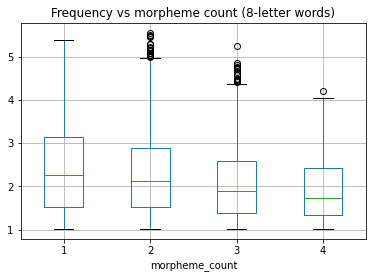

In [19]:
# example comparison:
df[df["length_letters"] == 8].sort_values("morpheme_count")

import matplotlib.pyplot as plt

subset = df[df["length_letters"] == 8]

subset.boxplot(column="frequency", by="morpheme_count")
plt.title("Frequency vs morpheme count (8-letter words)")
plt.suptitle("")
plt.show()

##### Plot correlation across the whole data set:

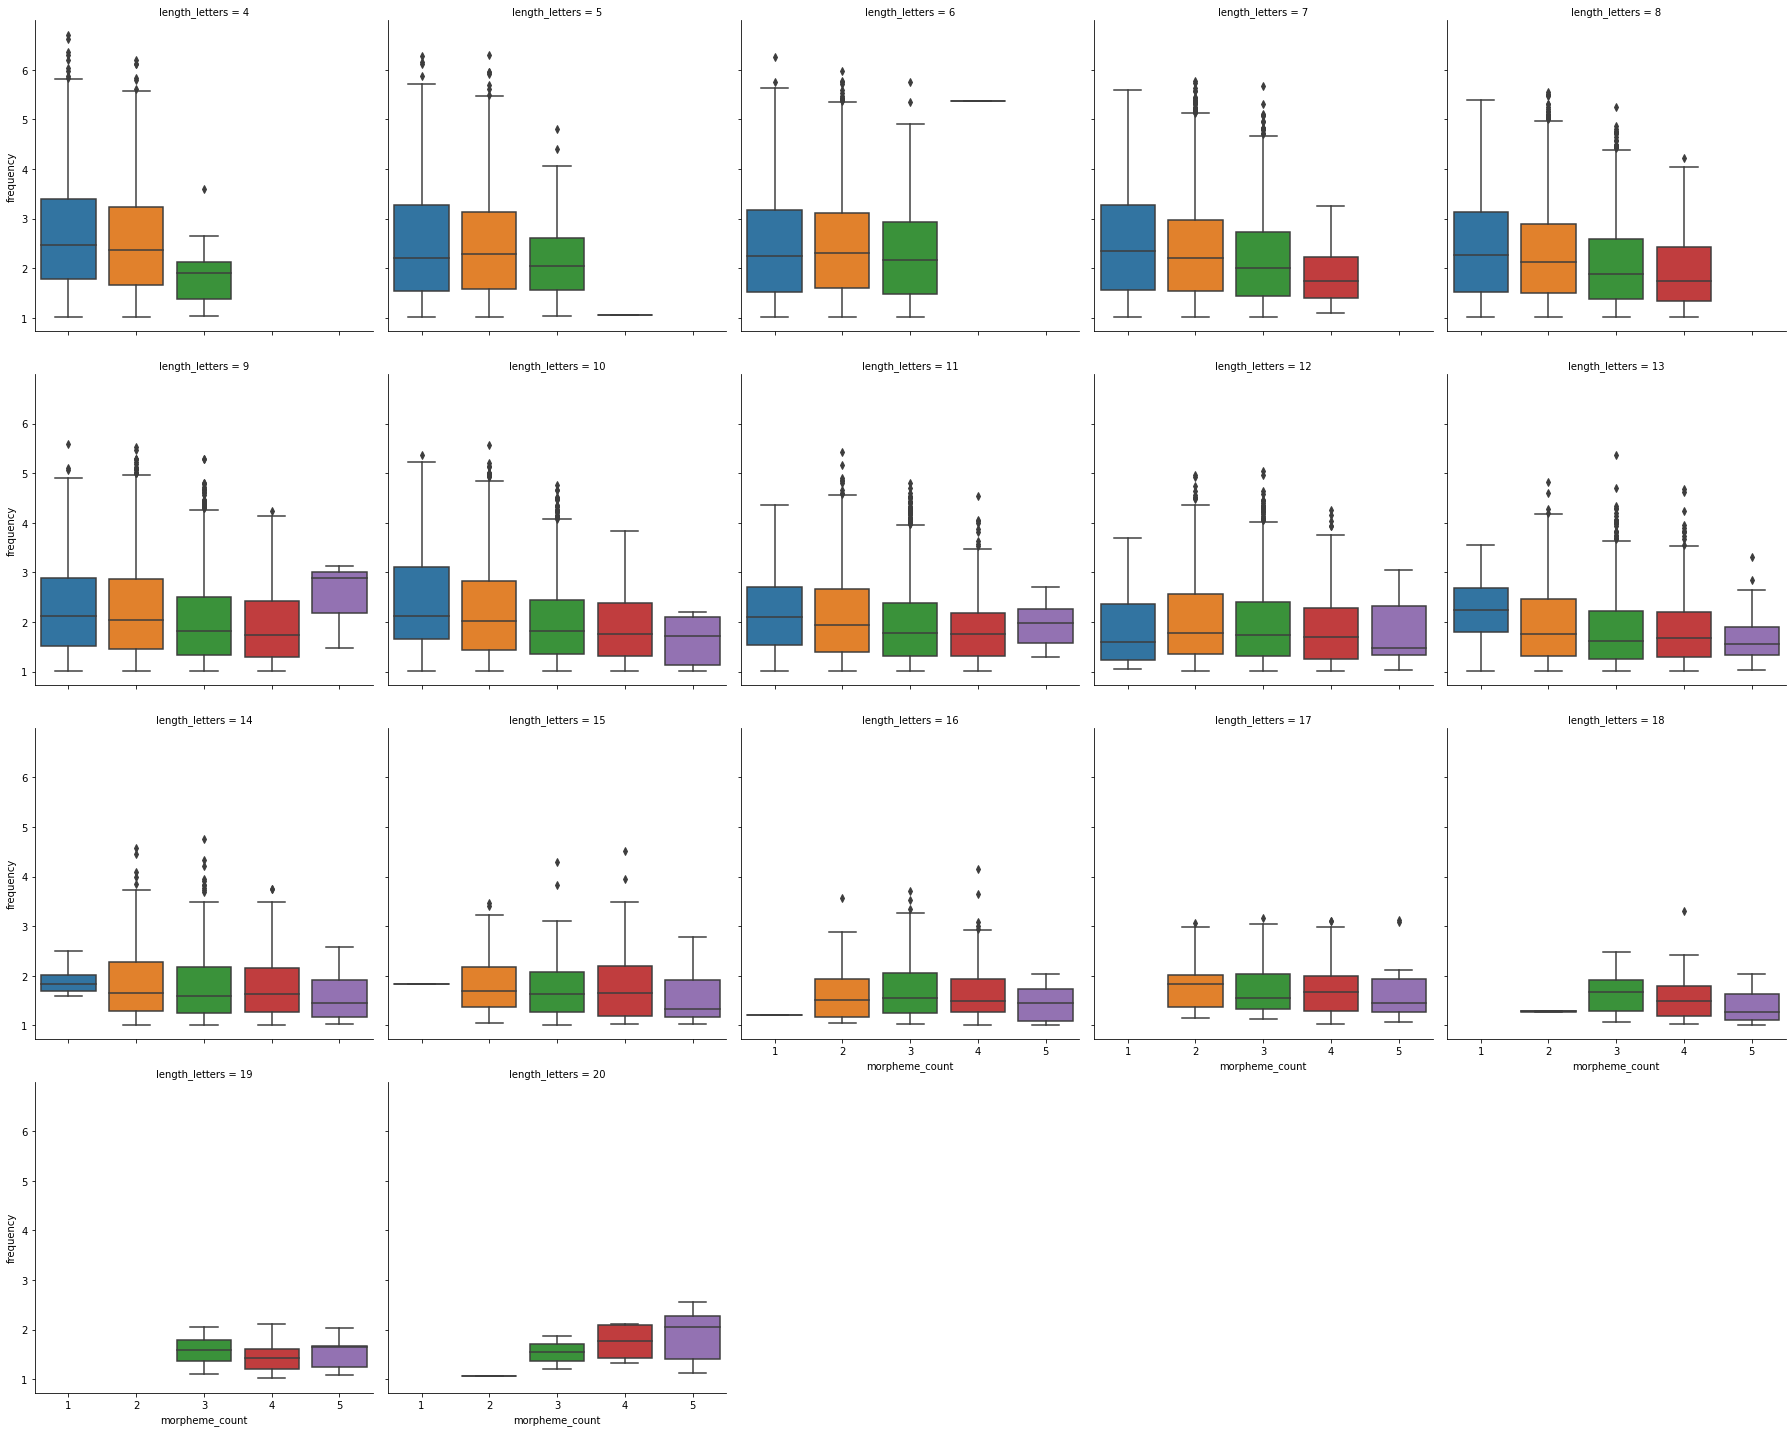

In [20]:
# facet plot by length

import seaborn as sns
import matplotlib.pyplot as plt

df_restr = df[(df["length_letters"] >= 4) & (df["length_letters"] <= 20)]

sns.catplot(
    data=df_restr,
    x="morpheme_count",
    y="frequency",
    col="length_letters",
    kind="box",
    col_wrap=5
)

#### Heatmap:

In [ ]:
df_restr2 = df[(df["length_letters"] > 4) & (df["length_letters"] <= 15)]

# only include words with 5-15 letters
# lots of non-words for '3', lots of wrong morpheme counts for '4'

summary = (
    df_restr2.groupby(["length_letters", "morpheme_count"])
      .agg(
          mean_frequency=("frequency", "mean"),
          word_count=("word", "count")
      )
      .reset_index()
)

# remove cells with fewer than 50 words:
summary = summary[summary["word_count"] >= 50]

print(summary)

In [22]:
heatmap_data = summary.pivot(
    index="length_letters",
    columns="morpheme_count",
    values="mean_frequency"
)

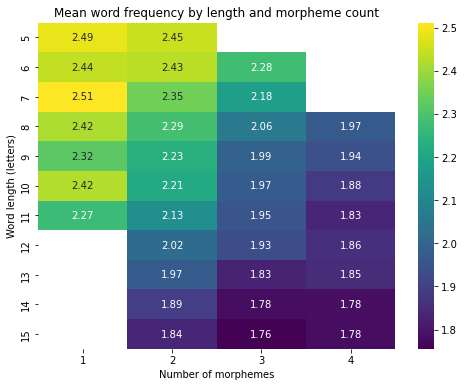

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.xlabel("Number of morphemes")
plt.ylabel("Word length (letters)")
plt.title("Mean word frequency by length and morpheme count")

plt.show()

##### Note: 
In addition to general length effect, there seems to be a tendency for morphologically simpler words to be more frequent (horizontal axis). This does not take any account of the frequency of morphemes in multi-morpheme words.

In [33]:
import statsmodels.formula.api as smf

model = smf.ols(
    "frequency ~ length_letters + morpheme_count",
    data=df_restr2
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              frequency   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1254.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:37:09   Log-Likelihood:                -71170.
No. Observations:               54000   AIC:                         1.423e+05
Df Residuals:                   53997   BIC:                         1.424e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.9961      0.016    182.

## Taking morpheme frequency into account 
(naive version, assuming that morphemes combine independently)

##### Count morpheme occurrences in the dataset:

In [ ]:
df_restr2.info()

In [34]:
import ast

df_restr2 = df_restr2.copy()
df_restr2["segments"] = df_restr2["segments"].apply(ast.literal_eval) # convert segments data into lists

from collections import Counter

morpheme_counts = Counter()

for segs in df_restr2["segments"]:
    for m in segs:
        morpheme_counts[m] += 1

In [ ]:
print(morpheme_counts)

##### Convert to probabilities:

In [35]:
total_morphemes = sum(morpheme_counts.values())

morpheme_probs = {
    m: c / total_morphemes
    for m, c in morpheme_counts.items()
}

In [ ]:
print(morpheme_probs)

##### Compute expected (log) probability of each word (simplified, assuming independence):

In [36]:
import numpy as np

def expected_log_prob(segments):
    return sum(np.log(morpheme_probs[m]) for m in segments)

# sums for each word the log probabilities of the morpheme
# expected frequency of the word based purely on its morphemes, assuming independence

df_restr2["expected_log_prob"] = df_restr2["segments"].apply(expected_log_prob)

print(df_restr2.sort_values(by="expected_log_prob", ascending=False).head())

         word   segments      segment_roles         segment_pos  \
32619   stone    [stone]           ['base']            ['Noun']   
33903   ables  [able, s]  ['base', 'affix']  ['Verb', 'Suffix']   
18384   meter    [meter]           ['base']            ['Noun']   
35560   hydro    [hydro]           ['base']            ['Noun']   
15768  master   [master]           ['base']            ['Noun']   

      original_segments      source subcategory  morpheme_count  \
32619         ['stone']  wiki_morph         NaN               1   
33903    ['able', '-s']  wiki_morph         NaN               2   
18384         ['meter']  wiki_morph         NaN               1   
35560         ['hydro']  wiki_morph         NaN               1   
15768        ['master']  wiki_morph         NaN               1   

       length_letters  frequency  expected_log_prob  
32619               5       4.80          -7.068140  
33903               5       1.73          -7.082736  
18384               5       4.09

In [ ]:
df_restr2.to_csv("morphology_frequency_dataset_restr2.csv", index=False)

##### Building a regression model:

In [37]:
import statsmodels.formula.api as smf

model = smf.ols(
    "frequency ~ length_letters + expected_log_prob + morpheme_count",
    data=df_restr2
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              frequency   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     1981.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:38:00   Log-Likelihood:                -69577.
No. Observations:               54000   AIC:                         1.392e+05
Df Residuals:                   53996   BIC:                         1.392e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4342      0.01

##### Plot:

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pick typical values for controls
median_length = df_restr2["length_letters"].median()
median_expected_log = df_restr2["expected_log_prob"].median()

# create a dataframe for predictions at different morpheme counts
pred_df = pd.DataFrame({
    "length_letters": [median_length]*5,
    "expected_log_prob": [median_expected_log]*5,
    "morpheme_count": np.arange(1,6)  # test 1–5 morphemes
})

# predicted frequencies
pred_df["predicted_frequency"] = model.predict(pred_df)

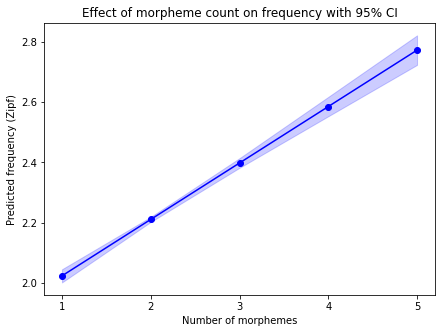

In [18]:
pred_ci = model.get_prediction(pred_df).summary_frame(alpha=0.05)

plt.figure(figsize=(7,5))
plt.plot(pred_df["morpheme_count"], pred_df["predicted_frequency"], marker="o", color="blue")
plt.fill_between(
    pred_df["morpheme_count"],
    pred_ci["mean_ci_lower"],
    pred_ci["mean_ci_upper"],
    color="blue",
    alpha=0.2
)

plt.xlabel("Number of morphemes")
plt.ylabel("Predicted frequency (Zipf)")
plt.title("Effect of morpheme count on frequency with 95% CI")
plt.xticks(pred_df["morpheme_count"])
plt.show()

##### Preliminary result:
- Generally, words with more morphemes tend to be less frequent.
- However, if we compare words built from equally frequent morphemes, complex words can be more frequent (productive morphological combinations tend to occur relatively frequently).

##### Potential problem:
- The predictor "expected_log_prob" predicts probabilities of words by simply multiplying independent morpheme probabilities, and underestimates the frequency of productive combinations that are very frequent.
- The model seems to attribute this extra observed frequency to morpheme_count, leading to a positive effect of morphological complexity.

## Second, slightly less naive version 
(partly taking morpheme structure into account, i.e. bases and affixes are treated separately)

##### Get the base morpheme:
(heuristic: longest morpheme in the word)

In [39]:
def get_base(segs):
    return max(segs, key=len)

df_restr2 = df_restr2.copy()
df_restr2["base"] = df_restr2["segments"].apply(get_base)

##### Base frequency:

In [40]:
from wordfreq import zipf_frequency # if not loaded already

df_restr2 = df_restr2.copy()
df_restr2["base_frequency"] = df_restr2["base"].apply(lambda w: zipf_frequency(w, "en"))

##### Get affixes:
(heuristic: everything except the base)

In [41]:
def get_affixes(segs):
    base = max(segs, key=len)
    return [m for m in segs if m != base]

df_restr2 = df_restr2.copy()
df_restr2["affixes"] = df_restr2["segments"].apply(get_affixes)

##### Estimate affix frequency:
- zipf_frequency() is not defined for affixes
- frequency of affixes is estimated from the segmentation dataset

##### Affix counter:

In [44]:
from collections import Counter

affix_counts = Counter()

for aff_list in df_restr2["affixes"]:
    for a in aff_list:
        affix_counts[a] += 1

In [ ]:
print(affix_counts)

###### Convert to frequencies:

In [46]:
total_affixes = sum(affix_counts.values())

affix_freq = {
    a: count / total_affixes
    for a, count in affix_counts.items()
}

In [ ]:
print(affix_freq)

###### Assign an affix-frequency score to each word:
(mean for multiple affixes)

In [65]:
import numpy as np

def affix_frequency(affixes):
    if len(affixes) == 0:
        return 0 # set affix_freq to 0 for mono-morphemic words
    return np.mean([affix_freq.get(a, 0) for a in affixes])

df_restr2["affix_frequency"] = df_restr2["affixes"].apply(affix_frequency)

In [66]:
analysis_df = df_restr2.dropna(
    subset=["frequency", "base_frequency"]
)

In [ ]:
analysis_df.sort_values(by="morpheme_count").head(10)

##### Regression model:
- holding base and affix frequency constant, adding another morpheme tends to reduce frequency
- (longer, more complex words are rarer unless they include very frequent affixes)

In [73]:
import statsmodels.formula.api as smf

model = smf.ols(
    "frequency ~ length_letters + morpheme_count + base_frequency + affix_frequency",
    data=analysis_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              frequency   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     2274.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:24:32   Log-Likelihood:                -68192.
No. Observations:               54000   AIC:                         1.364e+05
Df Residuals:                   53995   BIC:                         1.364e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.1872      0.019    1

##### Visualisation:

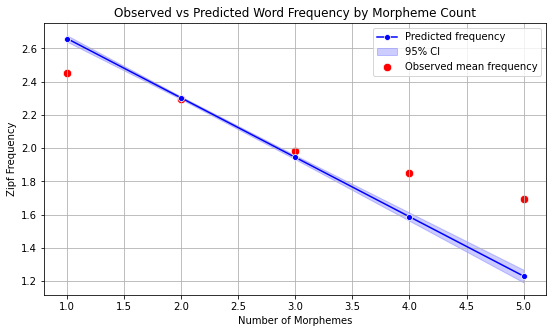

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# compute observed mean frequency per morpheme count
observed_means = (
    analysis_df.groupby("morpheme_count")["frequency"]
    .mean()
    .reset_index()
)

# prediction dataset
morpheme_range = np.arange(1, analysis_df["morpheme_count"].max() + 1)
mean_length = analysis_df["length_letters"].mean()
mean_base_freq = analysis_df["base_frequency"].mean()
mean_affix_freq = analysis_df["affix_frequency"].mean()

pred_df = pd.DataFrame({
    "morpheme_count": morpheme_range,
    "length_letters": mean_length,
    "base_frequency": mean_base_freq,
    "affix_frequency": mean_affix_freq
})

# get predicted values and 95% CI
predictions = model.get_prediction(pred_df)
pred_summary = predictions.summary_frame(alpha=0.05)

pred_df["predicted_frequency"] = pred_summary["mean"]
pred_df["ci_lower"] = pred_summary["mean_ci_lower"]
pred_df["ci_upper"] = pred_summary["mean_ci_upper"]

# plot
plt.figure(figsize=(9,5))

# predicted line with CI
sns.lineplot(
    x="morpheme_count",
    y="predicted_frequency",
    data=pred_df,
    marker="o",
    label="Predicted frequency",
    color="blue"
)
plt.fill_between(
    pred_df["morpheme_count"],
    pred_df["ci_lower"],
    pred_df["ci_upper"],
    color="blue",
    alpha=0.2,
    label="95% CI"
)

# observed mean frequency points
sns.scatterplot(
    x="morpheme_count",
    y="frequency",
    data=observed_means,
    color="red",
    s=70,
    label="Observed mean frequency"
)

plt.xlabel("Number of Morphemes")
plt.ylabel("Zipf Frequency")
plt.title("Observed vs Predicted Word Frequency by Morpheme Count")
plt.legend()
plt.grid(True)
plt.show()

##### Note:
- high-morpheme_count words are more frequent than predicted by the model
- complexity penalty seems to weaken for very high morpheme counts
- (high frequency of productive combinations of frequent affixes?)

In [ ]:
# adding quadratic term to the model
analysis_df["morpheme_count_sq"] = analysis_df["morpheme_count"]**2

model2 = smf.ols(
    "frequency ~ length_letters + morpheme_count + morpheme_count_sq + base_frequency + affix_frequency",
    data=analysis_df
).fit()

print(model2.summary())

## Conclusions:

- Generally, words with more morphemes are less frequent (negative morpheme_count coefficient), also if word length and morpheme frequency are controlled for.
- But: Productive combinations with frequent derivational/inflectional affixes can boost the frequency of complex words.
    - Just considering the frequency of combined morphemes leads to under-prediction of very productive combinations; the high actual frequency of some complex words then makes it look like frequency increases with morphological complexity.
    - High-frequency affixes (-s, -ed etc.) explain most of the extra frequency in multi-morpheme words.
    - In a model that accounts for this, the remaining effect of adding a morpheme is negative (complexity penalty).
    - The penalty seems to be reduced for very complex words.